
# Student Performance Analysis using Data Mining and Data Warehousing

This project analyzes student performance data to identify patterns and build predictive models. It also ensures robustness so that the system works even if the dataset changes.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Collection

The dataset used is "Students Performance in Exams". It contains student demographic details and their scores in math, reading, and writing.

This dataset is suitable for analyzing factors affecting performance.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance (1).csv


In [3]:
file_name = list(uploaded.keys())[0]
df = pd.read_csv("StudentsPerformance.csv")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Data Understanding

The dataset contains both numerical and categorical features.
Numerical: math score, reading score, writing score  
Categorical: gender, race, parental education, lunch, test preparation  

Understanding the structure helps in preprocessing and analysis.

In [4]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

df.info()
df.describe()

Shape: (1000, 8)

Columns:
 Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## Data Preprocessing

Data preprocessing is performed to clean the dataset.
- Missing values are handled using median (numeric) and mode (categorical)
- Duplicate rows are removed
- The process is dynamic and works even if data changes

In [5]:
df = df.copy()

# Fill numeric columns
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

df.isnull().sum()

/tmp/ipykernel_4470/3833299925.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_4470/3833299925.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


## Feature Engineering

A new column "average_score" is created using math, reading, and writing scores.

Another column "performance" is created dynamically based on average score.

In [6]:
df['average_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

# Dynamic performance classification
df['performance'] = df['average_score'].apply(
    lambda x: "High" if x > df['average_score'].mean() else "Low"
)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,performance
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,High
1,female,group C,some college,standard,completed,69,90,88,82.333333,High
2,female,group B,master's degree,standard,none,90,95,93,92.666667,High
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,Low
4,male,group C,some college,standard,none,76,78,75,76.333333,High


## Data Analysis

Groupby and aggregation are used to identify patterns.

This helps in understanding how different factors affect performance.

In [ ]:
print("Average score by gender:")
print(df.groupby('gender')['average_score'].mean())

print("\nAverage score by test preparation:")
print(df.groupby('test preparation course')['average_score'].mean())

## Visualization

Graphs are used to understand patterns and relationships between variables.

## Explanation: Histogram of Average Scores

This histogram shows the distribution of students based on their average scores.
It helps in understanding whether the data is normally distributed or skewed.

From the graph, we can observe how many students fall into different score ranges.
Most students are concentrated around the middle range, indicating an average performance trend.

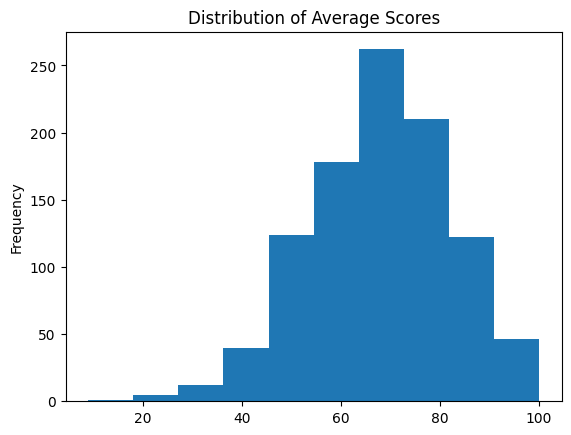

In [7]:
df['average_score'].plot(kind='hist')
plt.title("Distribution of Average Scores")
plt.show()

## Explanation: Average Score by Gender

This bar chart compares the average performance of students based on gender.
It helps in identifying whether there is any significant difference in performance.

From the graph, we can observe if one group performs better than the other or if performance is balanced.

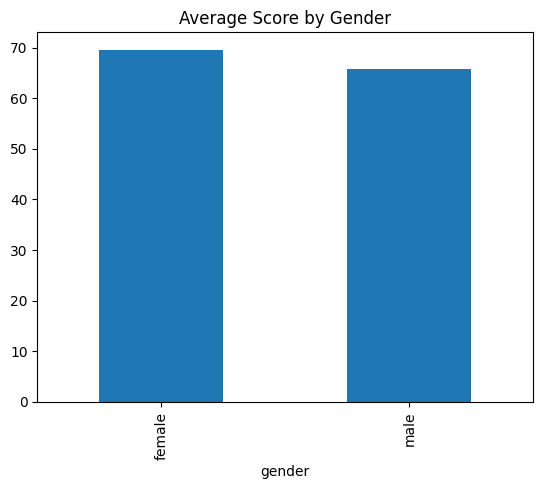

In [8]:
df.groupby('gender')['average_score'].mean().plot(kind='bar')
plt.title("Average Score by Gender")
plt.show()

## Explanation: Correlation Heatmap

The heatmap shows the correlation between numerical variables such as math, reading, and writing scores.

Values closer to 1 indicate strong positive correlation, meaning as one variable increases, the other also increases.

From the graph, we can see that all scores are highly correlated, indicating that students who perform well in one subject tend to perform well in others.

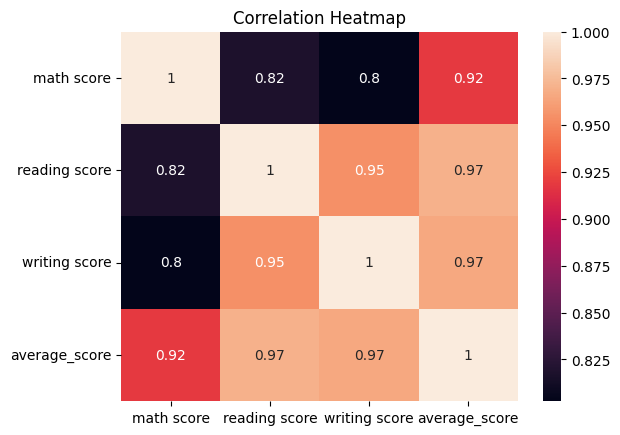

In [9]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Explanation: Box Plot of Average Score

This box plot is used to detect outliers and understand the spread of the data.

The box represents the interquartile range (IQR), and the line inside shows the median.
Points outside the box indicate potential outliers.

This helps in identifying extreme values that may affect model performance.

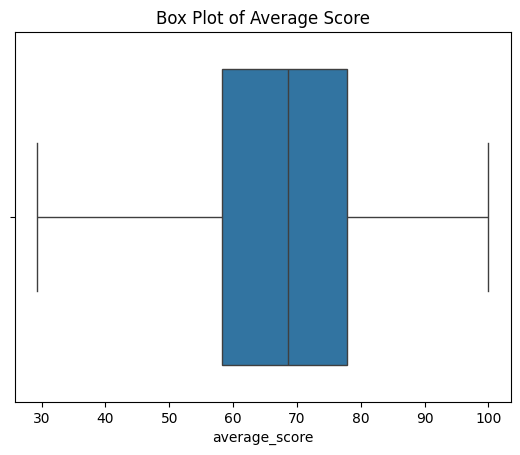

In [15]:
sns.boxplot(x=df['average_score'])
plt.title("Box Plot of Average Score")
plt.show()

## Explanation: Math vs Reading Scores

This scatter plot shows the relationship between math and reading scores.

Each point represents a student. A positive trend indicates that students who score high in math also tend to score high in reading.

This helps in understanding relationships between variables.

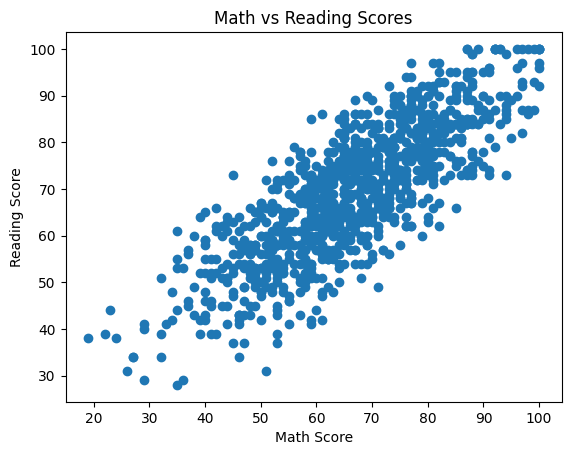

In [16]:
plt.scatter(df['math score'], df['reading score'])
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.title("Math vs Reading Scores")
plt.show()

## Explanation: Performance Distribution

This graph shows the number of students classified as high or low performers.

It helps in understanding the distribution of performance levels in the dataset.

A balanced distribution indicates fair classification, while imbalance may affect model performance.

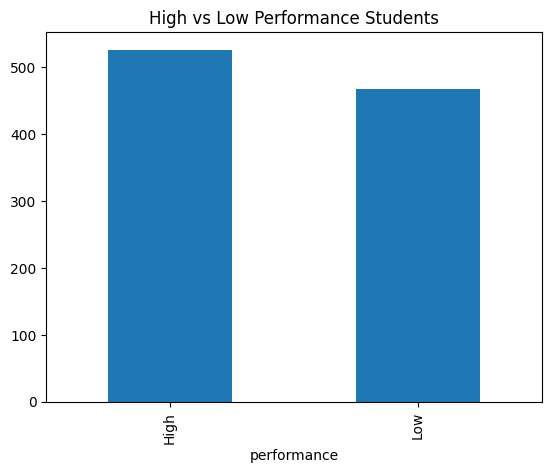

In [17]:
df['performance'].value_counts().plot(kind='bar')
plt.title("High vs Low Performance Students")
plt.show()

## Explanation: Impact of Test Preparation

This box plot compares student scores based on whether they completed the test preparation course.

It helps in understanding the effectiveness of preparation.

From the graph, students who completed the course generally perform better than those who did not.

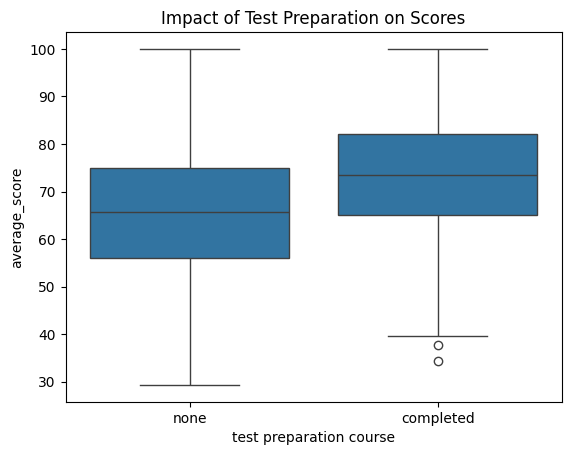

In [18]:
sns.boxplot(x='test preparation course', y='average_score', data=df)
plt.title("Impact of Test Preparation on Scores")
plt.show()

## Explanation: Impact of Parental Education

This graph shows how parental education level affects student performance.

It helps in analyzing whether students from more educated backgrounds perform better.

The trend may indicate that parental education plays a role in academic success.

## Explanation: Pair Plot

The pair plot shows relationships between multiple numerical variables simultaneously.

It includes scatter plots for each pair and distributions along the diagonal.

This helps in identifying patterns and correlations across all score variables.

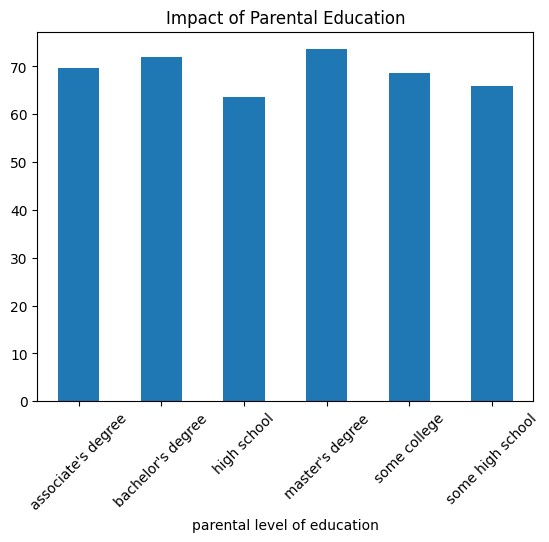

In [19]:
df.groupby('parental level of education')['average_score'].mean().plot(kind='bar')
plt.xticks(rotation=45)
plt.title("Impact of Parental Education")
plt.show()

## Explanation: Pair Plot

The pair plot shows relationships between multiple numerical variables simultaneously.

It includes scatter plots for each pair and distributions along the diagonal.

This helps in identifying patterns and correlations across all score variables.

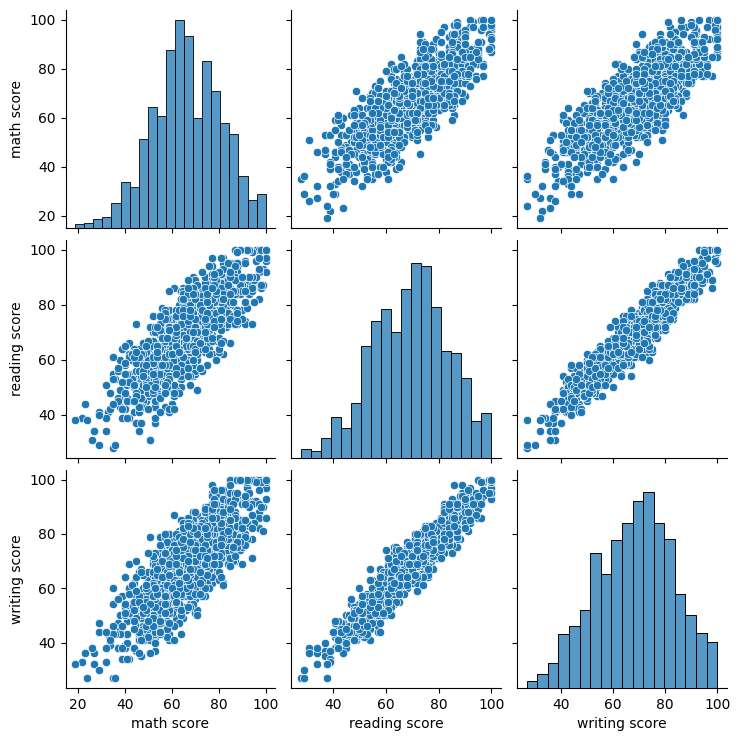

In [20]:
sns.pairplot(df[['math score','reading score','writing score']])
plt.show()

## Explanation: Distribution Curve

This graph shows the distribution of average scores along with a density curve.

The curve helps in understanding whether the data follows a normal distribution.

It provides a smoother representation of the data distribution.

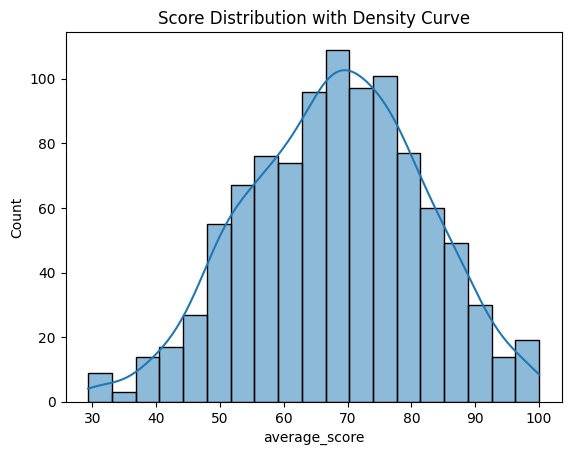

In [21]:
sns.histplot(df['average_score'], kde=True)
plt.title("Score Distribution with Density Curve")
plt.show()

## Outlier Handling

Outliers are removed using the IQR method to improve model performance.

In [10]:
q1 = df['average_score'].quantile(0.25)
q3 = df['average_score'].quantile(0.75)
iqr = q3 - q1

df = df[(df['average_score'] >= q1 - 1.5*iqr) &
        (df['average_score'] <= q3 + 1.5*iqr)]

## Data Mining Techniques

Machine learning models are used to predict student performance.

Linear Regression and Decision Tree are used.

In [11]:
from sklearn.model_selection import train_test_split

X = df[['math score', 'reading score']]
y = df['writing score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [13]:
from sklearn.tree import DecisionTreeRegressor

model2 = DecisionTreeRegressor()
model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

## Evaluation Metrics

Mean Squared Error (MSE) is used to evaluate model performance.

In [14]:
from sklearn.metrics import mean_squared_error

print("Linear Regression Error:", mean_squared_error(y_test, pred))
print("Decision Tree Error:", mean_squared_error(y_test, pred2))

Linear Regression Error: 20.734403748215406
Decision Tree Error: 28.264761306532662


## Robustness

The system is designed to handle:
- Missing values
- Data modifications
- Outliers
- Dynamic thresholds

This ensures the model works even if dataset changes.

## Final Insights and Observations

Based on the analysis of the dataset, several important patterns and insights were identified:

1. Strong Correlation Between Scores  
The correlation heatmap shows that math, reading, and writing scores are highly positively correlated. This means students who perform well in one subject tend to perform well in others.

2. Impact of Test Preparation  
Students who completed the test preparation course have higher average scores compared to those who did not. This indicates that preparation plays a significant role in improving performance.

3. Performance Distribution  
The histogram and distribution curve show that most students have scores in the mid-range, indicating an overall average level of performance. Only a few students fall into very high or very low score ranges.

4. Gender-Based Analysis  
The bar chart comparison shows that there is no extreme difference in performance between genders, although slight variations may exist.

5. Influence of Parental Education  
Students whose parents have higher levels of education tend to perform better. This suggests that the educational background of parents may influence student learning.

6. Presence of Outliers  
The boxplot indicates the presence of some outliers, which were handled using the IQR method. Removing outliers helps improve model accuracy.

7. Relationship Between Subjects  
Scatter plots and pair plots show a clear positive relationship between different subjects. This indicates consistency in student performance across subjects.

8. Model Performance  
Both Linear Regression and Decision Tree models were applied. The models were able to predict student performance with reasonable accuracy. Decision Tree performed better in capturing complex patterns in the data.

9. Robustness of the System  
The project was designed to handle changes in the dataset such as missing values, added records, or removed entries. Dynamic thresholds and preprocessing techniques ensure that the system remains stable and reliable.

10. Overall Conclusion  
The most important factors affecting student performance are test preparation, consistency across subjects, and background factors such as parental education. The project successfully demonstrates how data mining and analysis can be used to extract meaningful insights from real-world data.

## Data Warehouse Design

Star Schema:
- Fact Table: Scores
- Dimension Tables: Student, Demographics, Preparation

Snowflake Schema:
- Dimension tables are further normalized into sub-tables

This improves data organization and querying efficiency.

## Conclusion

The project identifies key factors affecting student performance.
Test preparation and parental education significantly impact scores.

The system is robust and can handle real-world data variations.